Custom modules:
Writing own nn.Module subclass with a custom forward method. Writing a custom loss function. Writing a custom optimizer (SGD from scratch using param.grad, then Adam). 

In [28]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [29]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.f1 = nn.Linear(784, 128)
        self.rel = nn.ReLU()
        self.f2 = nn.Linear(128, 10)

    def forward(self, x):
        f1_out = self.f1(x)
        rel_out = self.rel(f1_out)
        return self.f2(rel_out)

Data Loading

In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

Now that the nn.Module version is complete, we now move onto experimenting with a custom loss function
We'll write CrossEntropyLoss as an nn.Module subclass

In [31]:
model = Network()

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()
pytorch_loss = []
epochs = 5
lr = 0.05
for epoch in range(epochs):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.view(-1, 784)

        forward = model(images)
        loss = loss_fn(forward, labels)

        epoch_loss += loss

        loss.backward()

        with torch.no_grad():
            for param in model.parameters():
                param -= lr * param.grad

        for param in model.parameters():
            param.grad.zero_()

    print(f"Loss[{epoch}]: {epoch_loss}")
    pytorch_loss.append(epoch_loss.item())

Loss[0]: 481.7189636230469
Loss[1]: 214.419921875
Loss[2]: 149.151611328125
Loss[3]: 114.02006530761719
Loss[4]: 89.80218505859375


In [34]:
class CEL(nn.Module):
    def forward(self, X, y):
        exps = torch.exp(X - torch.max(X, dim=1, keepdim=True).values)
        probs = exps / torch.sum(exps, dim=1, keepdim=True)
        class_probability = probs[torch.arange(X.shape[0]), y]
        return torch.mean(-1 * torch.log(class_probability))

Adding and comparing new CEL version of loss_fn

In [36]:
model = Network()

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
loss_fn = CEL()
cel_loss = []
epochs = 5
lr = 0.05
for epoch in range(epochs):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.view(-1, 784)

        forward = model(images)
        loss = loss_fn(forward, labels)

        epoch_loss += loss

        loss.backward()

        with torch.no_grad():
            for param in model.parameters():
                param -= lr * param.grad

        for param in model.parameters():
            param.grad.zero_()

    print(f"Loss[{epoch}]: {epoch_loss}")
    cel_loss.append(epoch_loss.item())



Loss[0]: 486.9885559082031
Loss[1]: 216.34716796875
Loss[2]: 150.3193359375
Loss[3]: 115.9677734375
Loss[4]: 90.27889251708984


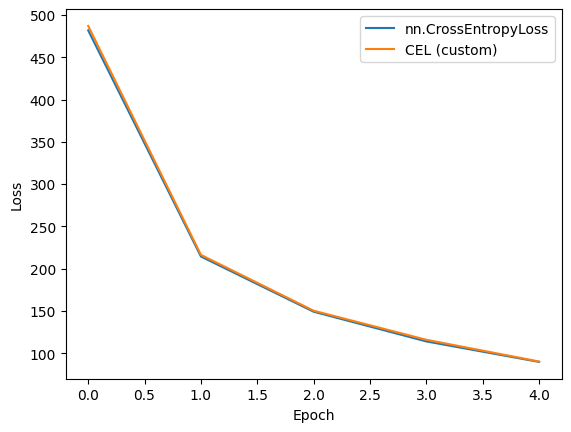

In [37]:
plt.plot([l.item() if hasattr(l, 'item') else l for l in pytorch_loss], label="nn.CrossEntropyLoss")
plt.plot(cel_loss, label="CEL (custom)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Next: Custom SGD optimizer

In [ ]:
class SGD:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for param in self.params:
                param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            param.grad.zero_()

Now rewriting training loop using SGD

In [ ]:
model = Network()
optimizer = SGD(model.parameters(), lr=0.05)
loss_fn = nn.CrossEntropyLoss()
epochs = 5
for epoch in range(epochs):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.view(-1, 784)
        forward = model(images)
        loss = loss_fn(forward, labels)

        epoch_loss += loss

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

    print(f"Loss[{epoch}]: {epoch_loss}")
